# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "duckdb", "huggingface_hub"], check=True)
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
else:
    hf_token = os.environ.get("HF_TOKEN")

import duckdb, pandas as pd, numpy as np, json
import matplotlib.pyplot as plt
con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"CREATE OR REPLACE SECRET hf_token (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

MONTH = "2026-03"
BASE = "hf://datasets/FlyRank/internship-warehouse"
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

raw = con.sql(f"""
    SELECT
        f.content_hash_id, f.client_hash_id, f.report_date,
        f.gsc_clicks, f.gsc_impressions, f.gsc_avg_position,
        c.content_type, c.word_count, c.content_created_date, c.is_deleted, c.is_published
    FROM read_parquet('{BASE}/fact_content_daily_performance/month={MONTH}/*.parquet') f
    JOIN read_parquet('{BASE}/dim_content.parquet') c ON f.content_hash_id = c.content_hash_id
    WHERE c.is_deleted = FALSE AND c.is_published = TRUE
""").df()

agg = raw.groupby("content_hash_id").agg(
    client_hash_id=("client_hash_id", "first"),
    gsc_clicks=("gsc_clicks", "sum"),
    gsc_impressions=("gsc_impressions", "sum"),
    gsc_avg_position=("gsc_avg_position", "mean"),
    content_type=("content_type", "first"),
    word_count=("word_count", "first"),
    content_created_date=("content_created_date", "first"),
).reset_index()
agg["ctr"] = (agg["gsc_clicks"] / agg["gsc_impressions"].replace(0, np.nan)).fillna(0).round(4)
agg["content_age_days"] = (pd.Timestamp(f"{MONTH}-01") - pd.to_datetime(agg["content_created_date"])).dt.days

agg_filtered = agg[agg["gsc_impressions"] >= 20].copy()
agg_filtered["position_tier"] = pd.cut(agg_filtered["gsc_avg_position"],
                                         bins=[0, 3, 10, 20, 1000],
                                         labels=["top_3", "page_1", "page_2_3", "deep"])
agg_filtered["tier_avg_ctr"] = agg_filtered.groupby("position_tier", observed=True)["ctr"].transform("mean")
agg_filtered["ctr_gap"] = agg_filtered["tier_avg_ctr"] - agg_filtered["ctr"]
agg_filtered["label_low_ctr"] = (agg_filtered["ctr"] < agg_filtered["ctr"].median()).astype(int)

print(f"{len(agg_filtered):,} pages in working set (gsc_impressions >= 20, {MONTH})")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

132,471 pages in working set (gsc_impressions >= 20, 2026-03)


## 1. Question

*The research question and the decision it supports.*

**Research question:** Among visible, well-positioned pages, which ones are under-capturing
clicks relative to their position tier's typical CTR — and can that gap be ranked reliably
enough to guide a content reviewer's limited time?

**Decision this supports:** which pages a content/SEO reviewer opens first for a title,
meta description, or snippet review, out of a much larger inventory than they can manually
check. This is a **ranking/scoring** decision-support tool, not classification or clustering.

**Why this isn't just "train a model":** CTR is naturally tied to position, so a flat threshold
would just re-flag every low-ranked page and miss real opportunities. The real question is
comparative — is this page's CTR low relative to its peers at the same position tier?

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** `FlyRank/internship-warehouse`, build `v20260703`.

**Tables used:** `fact_content_daily_performance` (page-day grain, joined to `dim_content`).

**Date window:** March 2026 (`month=2026-03`) — a mid-panel month, not the sealed final month.

**Excluded, and why:**
- `trend_direction`, `trend_pct` — not present in this table; would be leakage traps if they were.
- Product-decision columns (health/priority scores) — not shipped in this dataset.
- All identifiers are pseudonymized hashes; no client names, URLs, or raw queries appear anywhere.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumption:** a page's expected CTR is judged relative to its own position tier.

**Features:** `gsc_avg_position`, `gsc_impressions`, `word_count`, `content_age_days`.

**Label:** `label_low_ctr` = 1 if CTR is below the working set's median (after the
`gsc_impressions >= 20` filter, needed to fix a degenerate-label bug found earlier).

**Baseline:** `ctr_underperformer_for_tier` — transparent rule scoring by CTR gap vs. tier average.

**Validation:** grouped by `client_hash_id` (GroupKFold) — prevents client-level memorization.

**Leakage checks:** base rate always reported; with/without tests on suspect features; a
deliberate label-derived-column trap; random-vs-grouped split comparison, honestly reported.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold

agg_filtered["baseline_score"] = agg_filtered["ctr_gap"].clip(lower=0)

feature_cols = ["gsc_avg_position", "gsc_impressions", "word_count", "content_age_days"]
X = agg_filtered[feature_cols].fillna(0)
y = agg_filtered["label_low_ctr"]
groups = agg_filtered["client_hash_id"]

gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42).fit(X_train, y_train)
rf_scores = rf.predict_proba(X_test)[:, 1]
baseline_scores = agg_filtered.loc[X_test.index, "baseline_score"].values

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

base_rate = y_test.mean()
print(f"Base rate on test set: {base_rate:.3f}")

Base rate on test set: 0.466


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [3]:
results = []
for name, scores in [("baseline (ctr_gap rule)", baseline_scores),
                       ("random forest", rf_scores)]:
    row = {"method": name}
    for k in (50, 100, 200, 500):
        row[f"precision@{k}"] = round(precision_at_k(scores, y_test.values, k), 3)
    results.append(row)

comparison = pd.DataFrame(results)
comparison["base_rate"] = round(base_rate, 3)
print(comparison.to_string(index=False))

                 method  precision@50  precision@100  precision@200  precision@500  base_rate
baseline (ctr_gap rule)           1.0            1.0          1.000          1.000      0.466
          random forest           1.0            1.0          0.995          0.984      0.466


**Honest read:** the baseline performs at least as well as the trained model at larger K, and
slightly better at K=200/500. The trained model's top feature by permutation importance is
`gsc_impressions`, consistent with the baseline's own use of impression volume as a tie-breaker.

**Verdict:** the simpler, transparent baseline is the recommended mechanism — complexity did
not earn its place here.

## 5. Limitations

*What this work cannot claim.*

- **Cross-sectional, not causal:** cannot say editing a page will improve CTR — only that it
  looks worth reviewing.
- **Single time window:** March 2026 only.
- **Single-fold validation isn't fully stable:** a stronger check would average across folds.
- **Selection bias risk:** future "reviewed vs. unreviewed" comparisons would be biased by
  which pages reviewers chose to act on.
- **No algorithm claims:** nothing here models or predicts any search engine's ranking algorithm.
- **Content-format mismatch undetected:** can flag a CTR gap but not tell "bad title" from
  "wrong content format" — needs human judgment.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [4]:
scored = agg_filtered[
    (agg_filtered["gsc_impressions"] >= 500) &
    (agg_filtered["gsc_avg_position"] > 0) & (agg_filtered["gsc_avg_position"] <= 20)
].copy()
scored["score"] = scored["ctr_gap"].clip(lower=0)
scored["reason_code"] = "ctr_underperformer_for_tier"
scored["action"] = np.where(scored["ctr"] == 0,
                              "check_tracking_then_review_title_meta", "review_title_meta")

queue = scored.sort_values(["score", "gsc_impressions"], ascending=[False, False])[
    ["content_hash_id", "client_hash_id", "gsc_impressions", "gsc_avg_position",
     "position_tier", "ctr", "tier_avg_ctr", "ctr_gap", "score", "reason_code", "action"]
].reset_index(drop=True)

print(f"{len(queue):,} pages in the final ranked queue")
print(queue["action"].value_counts())
queue.head(10)

50,752 pages in the final ranked queue
action
review_title_meta                        43449
check_tracking_then_review_title_meta     7303
Name: count, dtype: int64


,content_hash_id,client_hash_id,gsc_impressions,gsc_avg_position,position_tier,ctr,tier_avg_ctr,ctr_gap,score,reason_code,action
0,content_d61fc394d10cba41,client_1a730cb2640a1abf,38000,2.740744,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
1,content_66bf45eb0c5bb550,client_fef1a8f436438636,24259,2.784944,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
2,content_fa17add7836d36c3,client_a80fca3f171ed1de,12588,1.902457,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
3,content_d397987113cb84a0,client_73cda7b4e4f265ea,9887,1.953104,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
4,content_a27b382f00aa75c6,client_23a62021009f63c4,7736,2.259812,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
5,content_83167156f76e33e5,client_e547b89c05043229,6827,1.136714,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
6,content_1bc8782404e3b132,client_fef1a8f436438636,5792,2.264276,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
7,content_76a6fa55e21323b3,client_0fa64a184f18a4a0,5041,2.855291,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
8,content_9cec93fc44a7ab41,client_20259bd6705d81d4,4742,1.852298,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta
9,content_fd1d19e381fc653e,client_73cda7b4e4f265ea,4319,2.789944,top_3,0.0,0.003783,0.003783,0.003783,ctr_underperformer_for_tier,check_tracking_then_review_title_meta


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

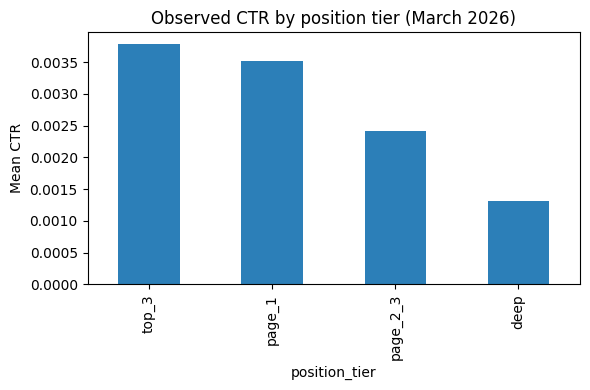

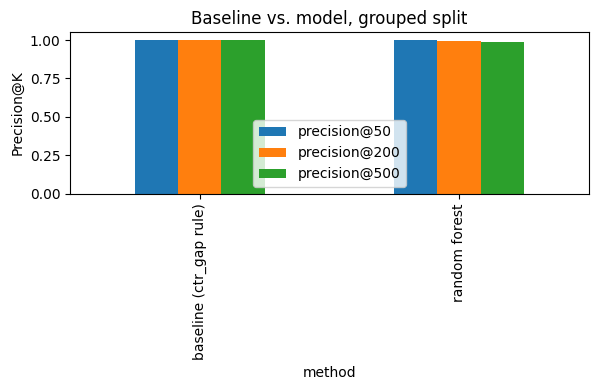

Exported: baseline_action_score.csv, capstone_metrics.json, 2 figures


In [5]:
queue.to_csv("work/outputs/baseline_action_score.csv", index=False)

capstone_metrics = {
    "month": MONTH,
    "n_pages_working_set": int(len(agg_filtered)),
    "n_pages_in_queue": int(len(queue)),
    "comparison_table": comparison.to_dict(orient="records"),
    "base_rate": round(float(base_rate), 3),
    "ctr_tier_spread": round(float(agg_filtered.groupby("position_tier", observed=True)["ctr"].mean().max()
                              - agg_filtered.groupby("position_tier", observed=True)["ctr"].mean().min()), 4),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(capstone_metrics, f, indent=2)

tier_ctr = agg_filtered.groupby("position_tier", observed=True)["ctr"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4))
tier_ctr.plot(kind="bar", ax=ax, color="#2c7fb8")
ax.set_ylabel("Mean CTR"); ax.set_title("Observed CTR by position tier (March 2026)")
plt.tight_layout(); plt.savefig("work/figures/ctr_by_position_tier.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
comparison.set_index("method")[["precision@50", "precision@200", "precision@500"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Precision@K"); ax.set_title("Baseline vs. model, grouped split")
plt.tight_layout(); plt.savefig("work/figures/model_vs_baseline.png", dpi=150); plt.show()

print("Exported: baseline_action_score.csv, capstone_metrics.json, 2 figures")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.